# How did Medicaid spending per recipient for substance use disorder treatment change across New York counties from 2023 to 2025, and which types of treatment services experienced the largest changes?
    ## Did spending per recipient increase or decrease between 2023 and 2025?
    ## Which counties experienced the largest increases?
    ## Which service categories experienced the greatest spending growth?
    ## Were spending trends different between fee-for-service and managed care?

#Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/ikiriinya/OASAS-Medicaid-Trend-Detailed-Recipient-Summary-Profile-Current-3-State-Fiscal-Year-Window/refs/heads/main/OASAS_Medicaid_Trend_Detailed_Recipient_Summary_Profile__Current_3_State_Fiscal_Year_Window_20260922.csv")

In [3]:
# Exploratory Data Analysis

In [4]:
df

,County,Services,Recipients,Claims,Dollars Recipients,Dollars Claims,Dollars,SFY
0,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,FFS2023
1,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,FFS2024
2,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,FFS2025
3,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,MC2023
4,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,MC2024
...,...,...,...,...,...,...,...,...
19393,Yates,All Medicaid Services,318,"51,019",13713.029843,85.472931,"$4,360,743.49",FFS2024
19394,Yates,All Medicaid Services,316,"59,223",14770.167975,78.810143,"$4,667,373.08",FFS2025
19395,Yates,All Medicaid Services,316,"59,223",10078.411961,58.109626,"$3,083,994.06",MC2023
19396,Yates,All Medicaid Services,316,"59,223",8468.487924,52.783848,"$2,692,979.16",MC2024


In [5]:
df.head()

,County,Services,Recipients,Claims,Dollars Recipients,Dollars Claims,Dollars,SFY
0,Albany,Clinic Other,0,0,0.0,0.0,$0.00,FFS2023
1,Albany,Clinic Other,0,0,0.0,0.0,$0.00,FFS2024
2,Albany,Clinic Other,0,0,0.0,0.0,$0.00,FFS2025
3,Albany,Clinic Other,0,0,0.0,0.0,$0.00,MC2023
4,Albany,Clinic Other,0,0,0.0,0.0,$0.00,MC2024


In [6]:
df.tail()

,County,Services,Recipients,Claims,Dollars Recipients,Dollars Claims,Dollars,SFY
19393,Yates,All Medicaid Services,318,"51,019",13713.029843,85.472931,"$4,360,743.49",FFS2024
19394,Yates,All Medicaid Services,316,"59,223",14770.167975,78.810143,"$4,667,373.08",FFS2025
19395,Yates,All Medicaid Services,316,"59,223",10078.411961,58.109626,"$3,083,994.06",MC2023
19396,Yates,All Medicaid Services,316,"59,223",8468.487924,52.783848,"$2,692,979.16",MC2024
19397,Yates,All Medicaid Services,316,"59,223",10863.378481,57.964433,"$3,432,827.60",MC2025


In [7]:
df.shape

(19398, 8)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19398 entries, 0 to 19397
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   County              19398 non-null  object 
 1   Services            19398 non-null  object 
 2   Recipients          19398 non-null  object 
 3   Claims              19398 non-null  object 
 4   Dollars Recipients  19398 non-null  float64
 5   Dollars Claims      19398 non-null  float64
 6   Dollars             19398 non-null  object 
 7   SFY                 19398 non-null  object 
dtypes: float64(2), object(6)
memory usage: 1.2+ MB


In [9]:
df.dtypes

County                 object
Services               object
Recipients             object
Claims                 object
Dollars Recipients    float64
Dollars Claims        float64
Dollars                object
SFY                    object
dtype: object

In [10]:
df.describe()

,Dollars Recipients,Dollars Claims
count,19398.000000,19398.000000
mean,3534.183783,219.903249
std,12406.078821,1070.270865
min,0.000000,0.000000
25%,0.000000,0.000000
50%,436.181689,14.468650
75%,3142.718350,118.819864
max,433567.480000,77804.270000


In [11]:
df.columns.tolist()

['County',
 'Services',
 'Recipients',
 'Claims',
 'Dollars Recipients',
 'Dollars Claims',
 'Dollars',
 'SFY']

# Understanding Services

In [12]:
service_list = (
    df[["Services"]]
    .drop_duplicates()
    .sort_values("Services")
    .reset_index(drop=True)
)

service_list

,Services
0,All Detoxification Services
1,All Inpatient (Inp) Services
2,All Medicaid Services
3,All Non SUD Services
4,All Opioid Treatment Services
5,All Outpatient (OP) Services
6,All Residential Services
7,All Substance Use Disorder (SUD) Services
8,Certified Community Behavioral Health Services
9,Children and Family Treatment and Support


In [13]:
number_of_services = df["Services"].nunique()

print("Number of service categories:", number_of_services)

Number of service categories: 53


# Clean and reorganize variables

In [14]:
###  Missing Data

####Missing-data analysis identifies variables that may require cleaning or special treatment before they are used in calculationsor visualizations.

missing_data = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_data = missing_data.sort_values(
    "Missing Values",
    ascending=False
)

missing_data

,Missing Values,Missing Percentage
County,0,0.0
Services,0,0.0
Recipients,0,0.0
Claims,0,0.0
Dollars Recipients,0,0.0
Dollars Claims,0,0.0
Dollars,0,0.0
SFY,0,0.0


### Separte the SFY into two variables.

In [15]:
df["Payment Type"] = df["SFY"].str.extract(r"(FFS|MC)")
df["Year"] = df["SFY"].str.extract(r"(\d{4})").astype(int)

In [16]:
df

,County,Services,Recipients,Claims,Dollars Recipients,Dollars Claims,Dollars,SFY,Payment Type,Year
0,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,FFS2023,FFS,2023
1,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,FFS2024,FFS,2024
2,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,FFS2025,FFS,2025
3,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,MC2023,MC,2023
4,Albany,Clinic Other,0,0,0.000000,0.000000,$0.00,MC2024,MC,2024
...,...,...,...,...,...,...,...,...,...,...
19393,Yates,All Medicaid Services,318,"51,019",13713.029843,85.472931,"$4,360,743.49",FFS2024,FFS,2024
19394,Yates,All Medicaid Services,316,"59,223",14770.167975,78.810143,"$4,667,373.08",FFS2025,FFS,2025
19395,Yates,All Medicaid Services,316,"59,223",10078.411961,58.109626,"$3,083,994.06",MC2023,MC,2023
19396,Yates,All Medicaid Services,316,"59,223",8468.487924,52.783848,"$2,692,979.16",MC2024,MC,2024


### Renaming columns

In [17]:
df = df.rename(
    columns={
        "Dollars Recipients": "Dollars Per Recipient",
        "Dollars Claims": "Dollars Per Claim"
}
)

### Removing commas from Recipients and Claims

####(regex=False tells pandas to treat the character you are replacing as ordinary text, rather than as a regular-expression pattern.
#replace )

In [18]:
df[["Recipients", "Claims", "Dollars"]].dtypes

Recipients    object
Claims        object
Dollars       object
dtype: object

In [19]:
df["Recipients"] = pd.to_numeric(
    df["Recipients"]
    .astype(str)
    .str.replace(",", "", regex=False),
    errors="coerce"
)

df["Claims"] = pd.to_numeric(
    df["Claims"]
    .astype(str)
    .str.replace(",", "", regex=False),
    errors="coerce"
)

### Removing the dollar sign and commas from Dollars

In [20]:
df["Dollars"] = pd.to_numeric(
    df["Dollars"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False),
    errors="coerce"
)

In [21]:
df

,County,Services,Recipients,Claims,Dollars Per Recipient,Dollars Per Claim,Dollars,SFY,Payment Type,Year
0,Albany,Clinic Other,0,0.0,0.000000,0.000000,0.00,FFS2023,FFS,2023
1,Albany,Clinic Other,0,0.0,0.000000,0.000000,0.00,FFS2024,FFS,2024
2,Albany,Clinic Other,0,0.0,0.000000,0.000000,0.00,FFS2025,FFS,2025
3,Albany,Clinic Other,0,0.0,0.000000,0.000000,0.00,MC2023,MC,2023
4,Albany,Clinic Other,0,0.0,0.000000,0.000000,0.00,MC2024,MC,2024
...,...,...,...,...,...,...,...,...,...,...
19393,Yates,All Medicaid Services,318,51019.0,13713.029843,85.472931,4360743.49,FFS2024,FFS,2024
19394,Yates,All Medicaid Services,316,59223.0,14770.167975,78.810143,4667373.08,FFS2025,FFS,2025
19395,Yates,All Medicaid Services,316,59223.0,10078.411961,58.109626,3083994.06,MC2023,MC,2023
19396,Yates,All Medicaid Services,316,59223.0,8468.487924,52.783848,2692979.16,MC2024,MC,2024


# Re-organize variables

In [22]:
analysis_df = df[
    [
        "County",
        "Services",
        "Year",
        "Payment Type",
        "Recipients",
        "Claims",
        "Dollars",
        "Dollars Per Recipient",
        "Dollars Per Claim"
    ]
].copy()

In [23]:
analysis_df.sample(10)

,County,Services,Year,Payment Type,Recipients,Claims,Dollars,Dollars Per Recipient,Dollars Per Claim
7147,Lewis,OP Peer Services,2024,FFS,0,0.0,0.00,0.000000,0.000000
15121,St.Lawrence,OP SUD for Youth (Freestanding),2024,FFS,0,0.0,0.00,0.000000,0.000000
18000,Washington,Office Mental Health (OMH) Licensed Psychiatri...,2023,FFS,43,2478.0,763836.53,17763.640233,308.247187
12165,Otsego,Inpatient Rehabilitation (OASAS),2023,MC,8,108.0,19715.04,3943.008000,394.300800
3014,Columbia,OP Peer Services,2025,FFS,0,0.0,0.00,0.000000,0.000000
17373,Ulster,Opioid Treatment (Buprenorphine),2023,MC,0,0.0,801.76,801.760000,200.440000
3715,Delaware,Opioid Treatment (Physician),2024,FFS,0,0.0,0.00,0.000000,0.000000
12551,Putnam,OP Clinic (Hospital),2025,MC,37,604.0,70667.50,1909.932432,116.999172
6080,Hamilton,DOH OP Other Services,2025,FFS,36,991.0,17840.94,495.581667,18.002967
15147,St.Lawrence,Opioid Treatment (Buprenorphine),2023,MC,9,101.0,28347.50,298.394737,17.975587


In [24]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19398 entries, 0 to 19397
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   County                 19398 non-null  object 
 1   Services               19398 non-null  object 
 2   Year                   19398 non-null  int64  
 3   Payment Type           19398 non-null  object 
 4   Recipients             19398 non-null  int64  
 5   Claims                 19398 non-null  float64
 6   Dollars                19398 non-null  float64
 7   Dollars Per Recipient  19398 non-null  float64
 8   Dollars Per Claim      19398 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 1.3+ MB


# Filter the substance-use-disorder services data for your main analysis

In [25]:
sud_df = analysis_df[
    analysis_df["Services"] ==
    "All Substance Use Disorder (SUD) Services"
].copy()

In [26]:
exclude_locations = ["Statewide", "NYS OMH", "NYS OMR/DD"]

county_sud_df = sud_df[
    ~sud_df["County"].isin(exclude_locations)
].copy()

In [27]:
county_sud_df["County"].nunique()

58

In [28]:
county_sud_df.groupby(
    ["County", "Year", "Payment Type"]
).size().value_counts()

1    348
Name: count, dtype: int64

In [29]:
county_sud_df.shape

(348, 9)

##  EXploratory Data  Analysis & Statistics

# Descriptive statistics

In [30]:
county_sud_df.describe()

,Year,Recipients,Claims,Dollars,Dollars Per Recipient,Dollars Per Claim
count,348.000000,348.000000,3.480000e+02,3.480000e+02,348.000000,348.000000
mean,2024.000000,4090.405172,5.721295e+05,1.732006e+07,2827.805520,41.432944
std,0.817672,12325.628060,2.215578e+06,7.541091e+07,3528.947780,29.507484
min,2023.000000,26.000000,8.960000e+02,2.458006e+04,186.232419,1.202529
25%,2023.000000,593.000000,3.376800e+04,8.542450e+05,981.149358,16.172390
50%,2024.000000,1361.000000,6.810000e+04,2.303392e+06,2195.524894,35.820553
75%,2025.000000,2666.000000,1.965930e+05,6.785829e+06,3477.474218,62.714328
max,2025.000000,96849.000000,2.033197e+07,8.242633e+08,37626.974576,170.635263


# Did spending increase or decrease?

In [31]:
yearly_summary = (
    county_sud_df
    .groupby(["Payment Type", "Year"])
    ["Dollars Per Recipient"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
    .reset_index()
)

yearly_summary

,Payment Type,Year,count,mean,median,std,min,max
0,FFS,2023,58,1103.94,794.30,960.81,186.23,5610.89
1,FFS,2024,58,1160.75,890.66,771.18,314.20,4093.96
2,FFS,2025,58,1680.03,1422.22,871.89,510.10,5261.06
3,MC,2023,58,4540.10,3043.94,6039.30,660.72,37626.97
4,MC,2024,58,4292.05,3490.72,3454.08,690.27,21103.32
5,MC,2025,58,4189.96,3307.11,3299.42,755.05,21284.09


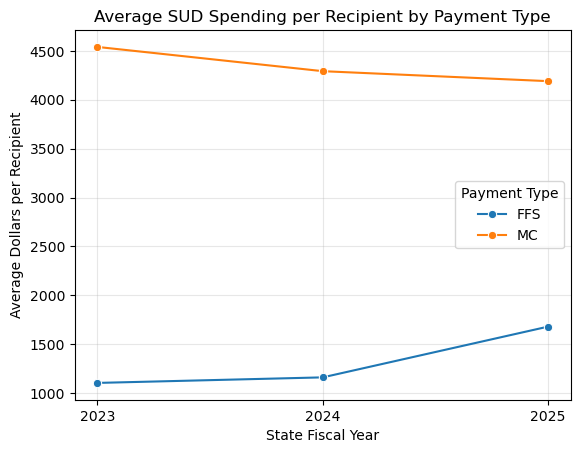

In [32]:
yearly_means = (
    county_sud_df
    .groupby(["Payment Type", "Year"], as_index=False)
    ["Dollars Per Recipient"]
    .mean()
)

sns.lineplot(
    data=yearly_means,
    x="Year",
    y="Dollars Per Recipient",
    hue="Payment Type",
    marker="o"
)

plt.title("Average SUD Spending per Recipient by Payment Type")
plt.xlabel("State Fiscal Year")
plt.ylabel("Average Dollars per Recipient")
plt.xticks([2023, 2024, 2025])
plt.grid(alpha=0.3)
plt.show()

In [33]:
# Annual statewide aggregate
annual_summary = df[df["Services"] == "All Substance Use Disorder (SUD) Services"].groupby("Year").agg({
    "Dollars": "sum",
    "Recipients": "sum"
}).reset_index()

annual_summary["Avg_Dollars_Per_Recipient"] = annual_summary["Dollars"] / annual_summary["Recipients"]
print(annual_summary)

   Year       Dollars  Recipients  Avg_Dollars_Per_Recipient
0  2023  4.212356e+09      939844                4481.973616
1  2024  3.709892e+09      934488                3969.973356
2  2025  4.140083e+09      976840                4238.240697


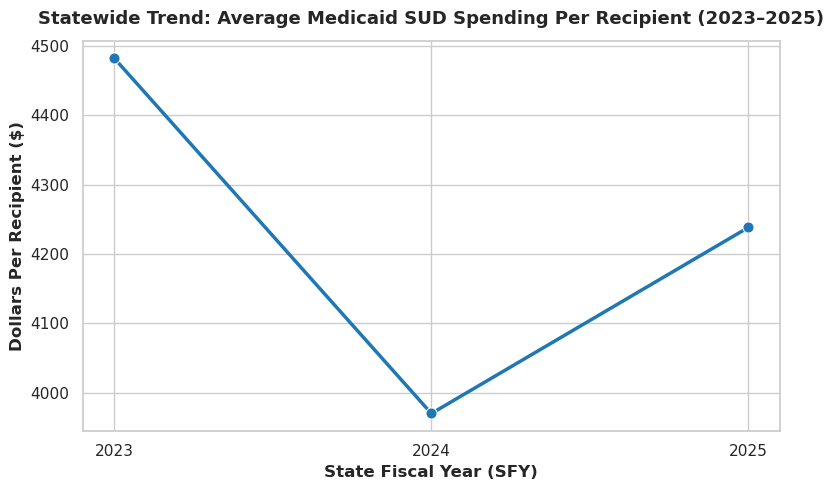

In [40]:
# Aggregate total dollars and recipients statewide for overall SUD services
statewide_sud_df = (
    df[df["Services"] == "All Substance Use Disorder (SUD) Services"]
    .groupby("Year")
    .agg({"Dollars": "sum", "Recipients": "sum"})
    .reset_index()
)
statewide_sud_df["Weighted_Dollars_Per_Recipient"] = (
    statewide_sud_df["Dollars"] / statewide_sud_df["Recipients"]
)

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=statewide_sud_df,
    x="Year",
    y="Weighted_Dollars_Per_Recipient",
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#1f77b4"
)

plt.title("Statewide Trend: Average Medicaid SUD Spending Per Recipient (2023–2025)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("State Fiscal Year (SFY)", fontweight="bold")
plt.ylabel("Dollars Per Recipient ($)", fontweight="bold")
plt.xticks([2023, 2024, 2025])
plt.tight_layout()
plt.show()

In [41]:
county_summary = county_sud_df.pivot_table(
    index="County", 
    columns="Year", 
    values="Dollars Per Recipient", 
    aggfunc="mean"
)
county_summary["Pct_Change"] = (
    (county_summary[2025] - county_summary[2023]) / county_summary[2023]
) * 100

In [42]:
# Statewide Spending & Recipient Trends (2023 - 2025)
# Calculates true weighted average spending per recipient per year
# -------------------------------------------------------------------------
annual_summary =statewide_sud_df.groupby('Year').agg(
    Total_Dollars=('Dollars', 'sum'),
    Total_Recipients=('Recipients', 'sum')
).reset_index()

annual_summary['Weighted_Dollars_Per_Recipient'] = (
    annual_summary['Total_Dollars'] / annual_summary['Total_Recipients']
)
annual_summary['Pct_Change_Spending'] = annual_summary['Total_Dollars'].pct_change() * 100

print("=== Statewide Annual Trends ===")
print(annual_summary.to_string(index=False))

=== Statewide Annual Trends ===
 Year  Total_Dollars  Total_Recipients  Weighted_Dollars_Per_Recipient  Pct_Change_Spending
 2023   4.212356e+09            939844                     4481.973616                  NaN
 2024   3.709892e+09            934488                     3969.973356           -11.928326
 2025   4.140083e+09            976840                     4238.240697            11.595770


In [43]:
# Aggregate spending and recipient totals by year
q1_summary = sud_df.groupby('Year').agg(
    Total_Spending=('Dollars', 'sum'),
    Total_Recipients=('Recipients', 'sum')
).reset_index()

# Calculate true weighted spending per recipient
q1_summary['Weighted_Spending_Per_Recipient'] = (
    q1_summary['Total_Spending'] / q1_summary['Total_Recipients']
)

# Calculate year-over-year percentage change
q1_summary['YoY_Spending_Change_%'] = q1_summary['Total_Spending'].pct_change() * 100
q1_summary['YoY_Per_Recipient_Change_%'] = q1_summary['Weighted_Spending_Per_Recipient'].pct_change() * 100

print(q1_summary)

   Year  Total_Spending  Total_Recipients  Weighted_Spending_Per_Recipient  \
0  2023    4.212356e+09            939844                      4481.973616   
1  2024    3.709892e+09            934488                      3969.973356   
2  2025    4.140083e+09            976840                      4238.240697   

   YoY_Spending_Change_%  YoY_Per_Recipient_Change_%  
0                    NaN                         NaN  
1             -11.928326                  -11.423545  
2              11.595770                    6.757409  


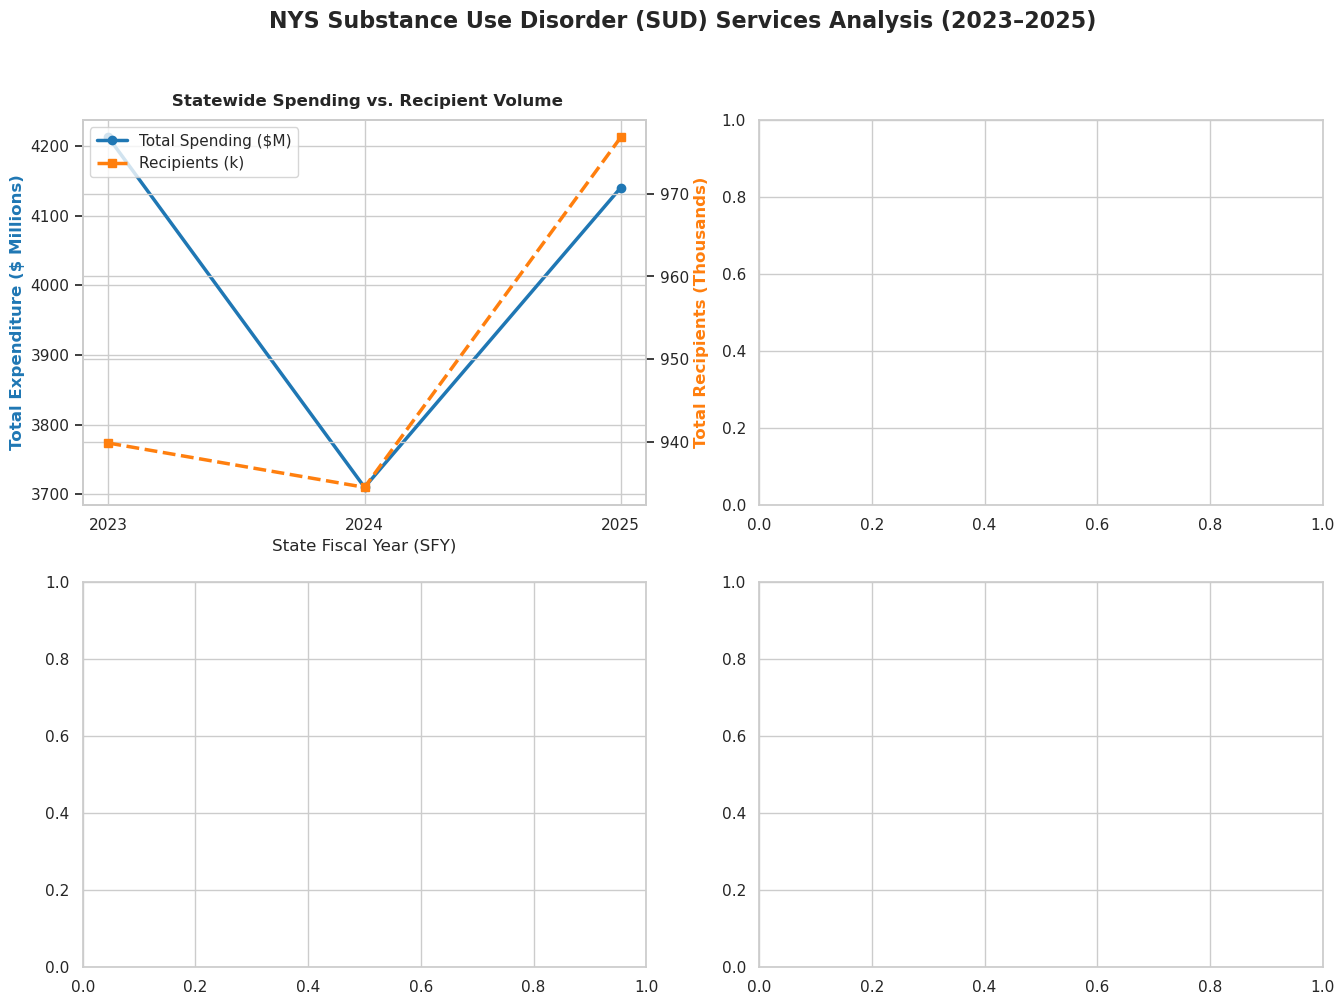

In [44]:
# Set overall aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 10})

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('NYS Substance Use Disorder (SUD) Services Analysis (2023–2025)', fontsize=16, fontweight='bold', y=0.98)

# Chart 1: Statewide Total Spending & Recipient Trends
# -------------------------------------------------------------------------
ax1 = axes[0, 0]
color1, color2 = '#1f77b4', '#ff7f0e'

ax1_twin = ax1.twinx()
p1 = ax1.plot(annual_summary['Year'], annual_summary['Total_Dollars'] / 1e6, marker='o', linewidth=2.5, color=color1, label='Total Spending ($M)')
p2 = ax1_twin.plot(annual_summary['Year'], annual_summary['Total_Recipients'] / 1e3, marker='s', linewidth=2.5, linestyle='--', color=color2, label='Recipients (k)')

ax1.set_title(' Statewide Spending vs. Recipient Volume', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('State Fiscal Year (SFY)')
ax1.set_ylabel('Total Expenditure ($ Millions)', color=color1, fontweight='bold')
ax1_twin.set_ylabel('Total Recipients (Thousands)', color=color2, fontweight='bold')
ax1.set_xticks([2023, 2024, 2025])

# Combine legends
lines = p1 + p2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Which counties changed the most?

In [45]:
county_pivot_df = df[df["Services"] == "All Substance Use Disorder (SUD) Services"].pivot_table(
    index="County", columns="Year", values="Dollars Per Recipient", aggfunc="mean"
)
county_pivot_df["Change_2023_2025"] = county_pivot_df[2025] - county_pivot_df[2023]
top_counties = county_pivot_df.sort_values("Change_2023_2025", ascending=False).head(10)

In [46]:
county_pivot_df

Year,2023,2024,2025,Change_2023_2025
County,,,,
Albany,2946.659581,3436.487068,4025.871421,1079.211840
Allegany,1898.894483,1814.107939,1978.073310,79.178827
Broome,2144.980934,2433.716175,2787.350476,642.369542
Cattaraugus,1923.757475,2048.922761,2476.096963,552.339488
Cayuga,1946.038969,2189.075708,2447.072774,501.033805
...,...,...,...,...
Washington,2169.378956,2168.234139,2056.057195,-113.321761
Wayne,1992.550597,2066.522271,2073.892733,81.342136
Westchester,3775.500464,3572.702773,3607.817373,-167.683091


/var/folders/vb/8wr6j2gx0v9fld5yt1l8km380000gn/T/ipykernel_58993/2142891745.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


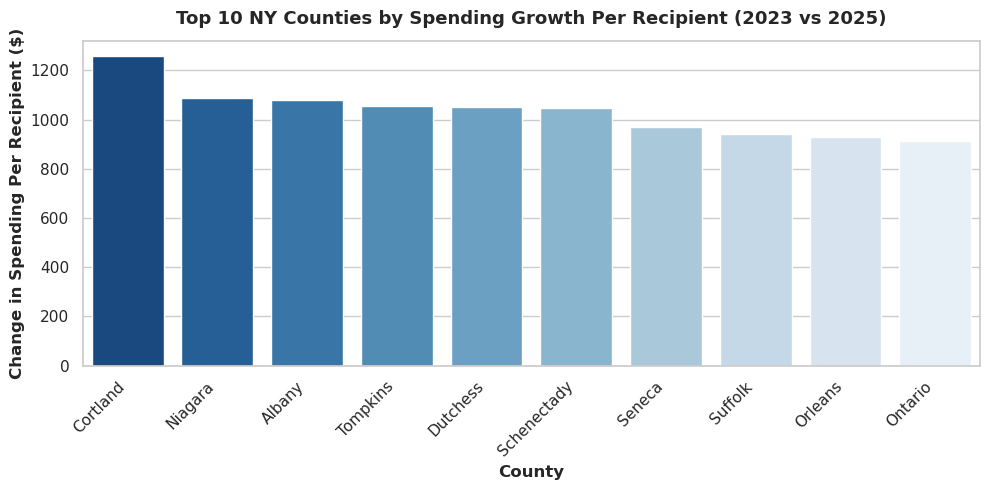

In [47]:
# Pivot county spending for overall SUD services to compare 2023 vs 2025
county_sud_df = df[df["Services"] == "All Substance Use Disorder (SUD) Services"]
county_pivot_df = county_sud_df.pivot_table(
    index="County", columns="Year", values="Dollars Per Recipient", aggfunc="mean"
).dropna()

county_pivot_df["Growth"] = county_pivot_df[2025] - county_pivot_df[2023]
top10_counties = county_pivot_df.sort_values(by="Growth", ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top10_counties,
    x="County",
    y="Growth",
    palette="Blues_r"
)

plt.title("Top 10 NY Counties by Spending Growth Per Recipient (2023 vs 2025)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("County", fontweight="bold")
plt.ylabel("Change in Spending Per Recipient ($)", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Fee For Service

In [48]:
## Fee For Service

ffs_counties = county_sud_df[
    county_sud_df["Payment Type"] == "FFS"
].copy()

ffs_change = ffs_counties.pivot(
    index="County",
    columns="Year",
    values="Dollars Per Recipient"
).reset_index()

In [49]:
ffs_counties

,County,Services,Recipients,Claims,Dollars Per Recipient,Dollars Per Claim,Dollars,SFY,Payment Type,Year
306,Albany,All Substance Use Disorder (SUD) Services,2806,229762.0,720.572167,8.800087,2021925.50,FFS2023,FFS,2023
307,Albany,All Substance Use Disorder (SUD) Services,2798,218995.0,1060.319042,13.547217,2966772.68,FFS2024,FFS,2024
308,Albany,All Substance Use Disorder (SUD) Services,2734,196593.0,1624.267915,22.588538,4440748.48,FFS2025,FFS,2025
624,Allegany,All Substance Use Disorder (SUD) Services,590,32841.0,781.234678,14.035153,460928.46,FFS2023,FFS,2023
625,Allegany,All Substance Use Disorder (SUD) Services,609,32015.0,809.259179,15.393998,492838.84,FFS2024,FFS,2024
...,...,...,...,...,...,...,...,...,...,...
19069,Wyoming,All Substance Use Disorder (SUD) Services,703,17271.0,2969.104026,120.854619,2087280.13,FFS2024,FFS,2024
19070,Wyoming,All Substance Use Disorder (SUD) Services,676,18224.0,3479.853935,129.081500,2352381.26,FFS2025,FFS,2025
19386,Yates,All Substance Use Disorder (SUD) Services,306,8514.0,441.188464,15.856668,135003.67,FFS2023,FFS,2023
19387,Yates,All Substance Use Disorder (SUD) Services,318,8092.0,551.590346,21.676437,175405.73,FFS2024,FFS,2024


In [50]:
## Calculate dollar and percentage Changes

ffs_change["Dollar_Change"] = (
    ffs_change[2025] - ffs_change[2023]
)

ffs_change["Percent_Change"] = (
    (ffs_change[2025] - ffs_change[2023]) /
    ffs_change[2023]
) * 100

In [51]:
## CLeaning Data

ffs_change["Percent_Change"] = (
    ffs_change["Percent_Change"]
    .replace([np.inf, -np.inf], np.nan)
)

#Counties with the largest dollar increases:

In [52]:
ffs_largest_increases = (
    ffs_change
    .sort_values("Dollar_Change", ascending=False)
    .head(10)
)

ffs_largest_increases

Year,County,2023,2024,2025,Dollar_Change,Percent_Change
6,Chemung,458.524471,651.325035,2360.214247,1901.689776,414.741175
56,Washington,484.340773,556.390616,2187.138728,1702.797955,351.570227
55,Warren,852.954461,902.574181,2320.292472,1467.338011,172.030053
8,Clinton,918.952136,912.704322,2347.394508,1428.442372,155.442521
34,Ontario,717.456337,892.548887,2070.362281,1352.905944,188.569795
46,Seneca,511.179514,540.700416,1838.202300,1327.022786,259.600150
21,Jefferson,610.673918,888.769678,1740.108416,1129.434498,184.948868
32,Oneida,598.116701,744.073636,1720.933961,1122.817260,187.725449
47,St.Lawrence,946.623483,1245.599125,1945.107696,998.484213,105.478496
0,Albany,720.572167,1060.319042,1624.267915,903.695748,125.413635


In [53]:
# Counties with the largest decreases:

In [54]:
ffs_largest_decreases = (
    ffs_change
    .sort_values("Dollar_Change")
    .head(10)
)

ffs_largest_decreases

Year,County,2023,2024,2025,Dollar_Change,Percent_Change
19,Hamilton,1981.073077,1152.805517,1273.869459,-707.203617,-35.698008
41,Rockland,5610.893608,4093.956098,5261.064662,-349.828947,-6.234817
35,Orange,4025.254729,3638.511621,3742.639301,-282.615428,-7.021057
22,Lewis,884.342031,522.688653,683.191711,-201.150319,-22.745760
9,Columbia,526.665556,855.100866,510.097204,-16.568352,-3.145896
18,Greene,801.788788,689.118619,886.909952,85.121164,10.616407
7,Chenango,627.783372,470.458456,714.282646,86.499274,13.778523
57,Wayne,983.997654,814.399076,1082.744566,98.746911,10.035279
28,NYS OMH,2576.881596,2772.655105,2853.874596,276.993000,10.749155
15,Franklin,3005.783566,2963.435266,3285.891774,280.108208,9.318975


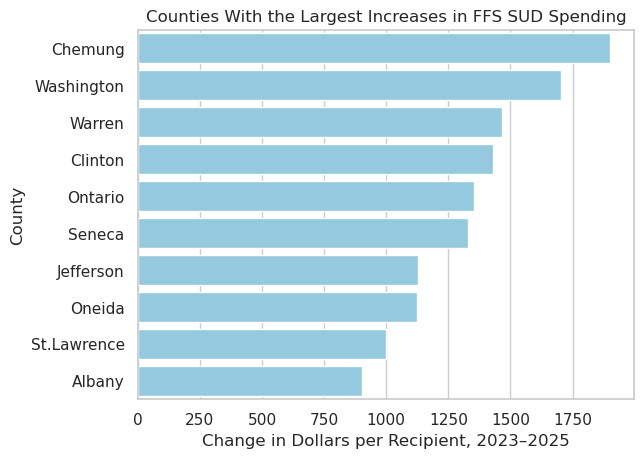

In [55]:
sns.barplot(
    data= ffs_largest_increases,
    x="Dollar_Change",
    y="County",
    color="skyblue"
)

plt.title("Counties With the Largest Increases in FFS SUD Spending")
plt.xlabel("Change in Dollars per Recipient, 2023–2025")
plt.ylabel("County")
plt.show()

In [56]:
## Managed Care

In [57]:
mc_counties = county_sud_df[
    county_sud_df["Payment Type"] == "MC"
].copy()

mc_change = mc_counties.pivot(
    index="County",
    columns="Year",
    values="Dollars Per Recipient"
).reset_index()

display(mc_change)

Year,County,2023,2024,2025
0,Albany,5172.746996,5812.655093,6427.474927
1,Allegany,3016.554288,2818.956700,2771.546444
2,Broome,3514.609909,4074.532236,4508.553856
3,Cattaraugus,2583.018974,2871.512010,3221.014853
4,Cayuga,2982.622927,3555.197697,3657.169887
...,...,...,...,...
56,Washington,3854.417139,3780.077661,1924.975662
57,Wayne,3001.103539,3318.645466,3065.040899
58,Westchester,6179.021809,5872.478031,4945.874422
59,Wyoming,660.720297,690.265249,972.604467


In [58]:
mc_change["Dollar_Change"] = mc_change[2025] - mc_change[2023]

mc_change["Percent_Change"] = (
    mc_change["Dollar_Change"]
    / mc_change[2023].replace(0, float("nan"))
) * 100

display(
    mc_change.sort_values("Dollar_Change", ascending=False).head(10)
)

Year,County,2023,2024,2025,Dollar_Change,Percent_Change
10,Cortland,2589.273481,3476.680979,4701.859954,2112.586473,81.589932
31,Niagara,2681.070105,3754.414168,4429.630260,1748.560155,65.218741
53,Tompkins,2714.330895,3293.535396,4438.600593,1724.269698,63.524668
43,Schenectady,3661.482700,4825.866795,5267.423538,1605.940839,43.860397
9,Columbia,3767.049411,4536.188481,5371.226175,1604.176764,42.584436
12,Dutchess,5823.108775,6328.408427,7235.519767,1412.410992,24.255274
50,Suffolk,5765.104093,6348.971227,7140.125858,1375.021765,23.850771
18,Greene,4011.515882,4907.410082,5375.698705,1364.182823,34.006666
36,Orleans,1961.811745,2576.955943,3273.924141,1312.112396,66.882686
0,Albany,5172.746996,5812.655093,6427.474927,1254.727931,24.256511


In [59]:
### Dollar And Percantage Changes

mc_change["Dollar_Change"] = (
    mc_change[2025] - mc_change[2023]
)

mc_change["Percent_Change"] = (
    (mc_change[2025] - mc_change[2023]) /
    mc_change[2023]
) * 100

In [60]:
### Data Cleaning for counties had no spending  in 2023

mc_change["Percent_Change"] = (
    mc_change["Percent_Change"]
    .replace([np.inf, -np.inf], np.nan)
)

## Counties with the largest dollar increases under Managed Care

In [61]:
mc_largest_increases = (
    mc_change
    .sort_values("Dollar_Change", ascending=False)
    .head(10)
)

mc_largest_increases

Year,County,2023,2024,2025,Dollar_Change,Percent_Change
10,Cortland,2589.273481,3476.680979,4701.859954,2112.586473,81.589932
31,Niagara,2681.070105,3754.414168,4429.630260,1748.560155,65.218741
53,Tompkins,2714.330895,3293.535396,4438.600593,1724.269698,63.524668
43,Schenectady,3661.482700,4825.866795,5267.423538,1605.940839,43.860397
9,Columbia,3767.049411,4536.188481,5371.226175,1604.176764,42.584436
12,Dutchess,5823.108775,6328.408427,7235.519767,1412.410992,24.255274
50,Suffolk,5765.104093,6348.971227,7140.125858,1375.021765,23.850771
18,Greene,4011.515882,4907.410082,5375.698705,1364.182823,34.006666
36,Orleans,1961.811745,2576.955943,3273.924141,1312.112396,66.882686
0,Albany,5172.746996,5812.655093,6427.474927,1254.727931,24.256511


## Counties with the largest decreases under the managed care

In [62]:
mc_largest_decreases = (
    mc_change
    .sort_values("Dollar_Change")
    .head(10)
)

mc_largest_decreases

Year,County,2023,2024,2025,Dollar_Change,Percent_Change
41,Rockland,37626.974576,21103.320724,21284.094709,-16342.879867,-43.433946
35,Orange,30198.125387,19612.122560,16469.456116,-13728.669271,-45.461992
51,Sullivan,15201.659059,9383.921365,9130.582934,-6071.076125,-39.936931
27,NY City,9631.831569,8588.462255,7377.131158,-2254.700412,-23.408844
55,Warren,4677.596365,4758.144260,2435.962821,-2241.633543,-47.922766
32,Oneida,4122.127900,4407.734795,2132.747625,-1989.380275,-48.261003
56,Washington,3854.417139,3780.077661,1924.975662,-1929.441477,-50.057931
48,Statewide,7438.397368,6418.990852,5928.801216,-1509.596151,-20.294642
8,Clinton,2810.332768,2807.883381,1479.530894,-1330.801874,-47.353890
58,Westchester,6179.021809,5872.478031,4945.874422,-1233.147387,-19.957000


## Graph the largest increases:

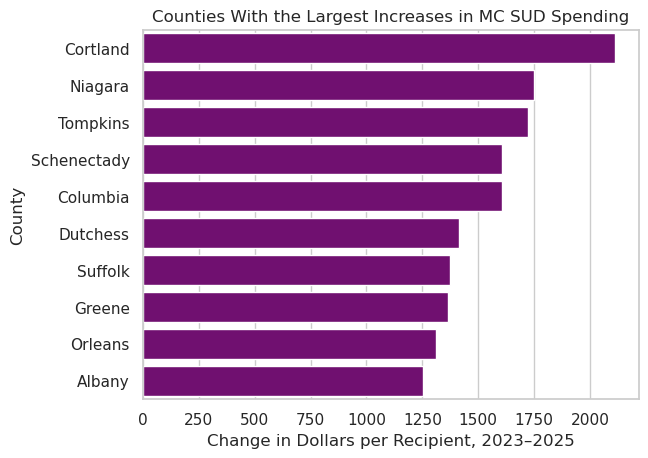

In [63]:
sns.barplot(
    data=mc_largest_increases,
    x="Dollar_Change",
    y="County",
    color="Purple"
)

plt.title("Counties With the Largest Increases in MC SUD Spending")
plt.xlabel("Change in Dollars per Recipient, 2023–2025")
plt.ylabel("County")
plt.show()

In [64]:
# Aggregate total spending by Payment Type and Year
payment_summary = (
    df.groupby(["Payment Type", "Year"])["Dollars"]
    .sum()
    .reset_index()
)

  Payment Type  Year       Dollars  Dollars_Millions
0          FFS  2023  4.264544e+08        426.454388
1          FFS  2024  4.225713e+08        422.571336
2          FFS  2025  6.212536e+08        621.253596
3           MC  2023  1.678445e+09       1678.444737
4           MC  2024  1.431308e+09       1431.308116
5           MC  2025  1.447350e+09       1447.349737


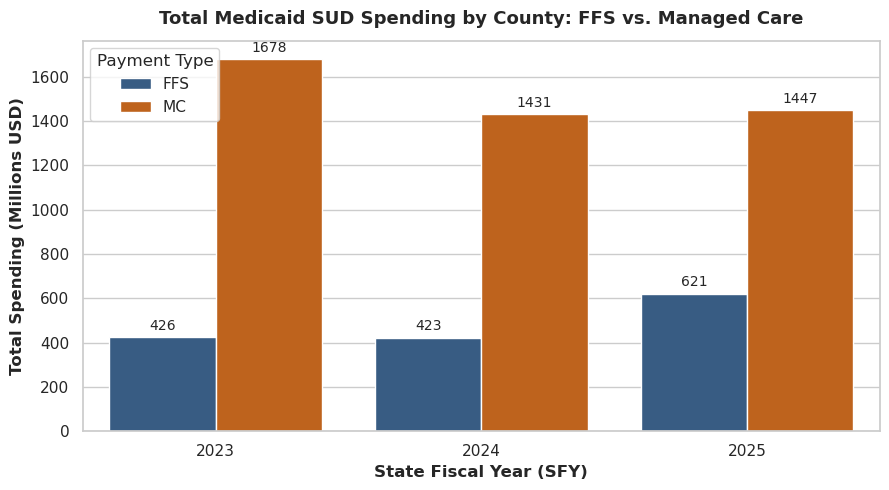

In [65]:
exclude_locations = ["Statewide", "NYS OMH", "NYS OMR/DD"]

# One row per county x year x payment type: the "All SUD" total only, no statewide rows
county_total = df[
    (df["Services"] == "All Substance Use Disorder (SUD) Services") &
    (~df["County"].isin(exclude_locations))
]

payment_summary = (
    county_total.groupby(["Payment Type", "Year"])["Dollars"]
    .sum()
    .reset_index()
)
payment_summary["Dollars_Millions"] = payment_summary["Dollars"] / 1e6
print(payment_summary)  # sanity check before plotting

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=payment_summary,
    x="Year", y="Dollars_Millions", hue="Payment Type",
    palette=["#2b5c8f", "#d95f02"]
)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", padding=3)

plt.title("Total Medicaid SUD Spending by County: FFS vs. Managed Care",
          fontsize=13, fontweight="bold", pad=12)
plt.xlabel("State Fiscal Year (SFY)", fontweight="bold")
plt.ylabel("Total Spending (Millions USD)", fontweight="bold")
plt.legend(title="Payment Type", frameon=True)
plt.tight_layout()
plt.show()

/var/folders/vb/8wr6j2gx0v9fld5yt1l8km380000gn/T/ipykernel_58993/3424546976.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


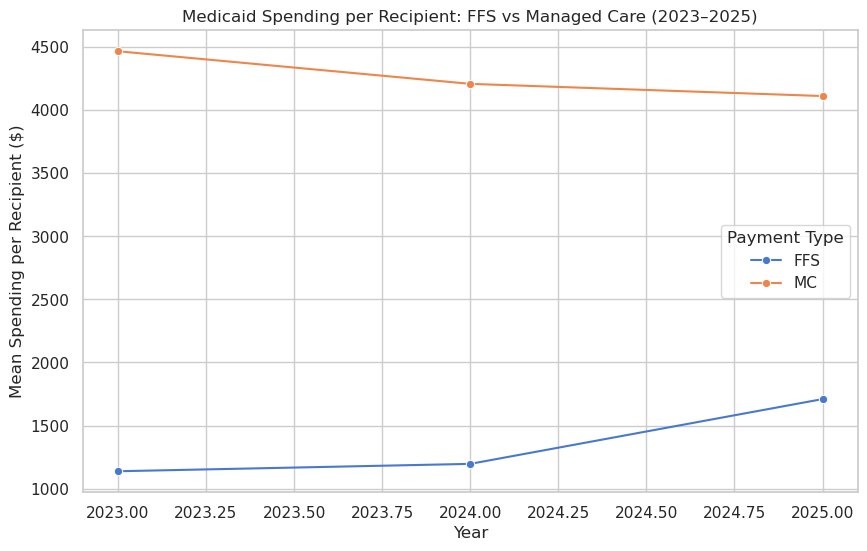

In [66]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=county_sud_df, 
    x="Year", 
    y="Dollars Per Recipient", 
    hue="Payment Type", 
    marker="o", 
    ci=None
)
plt.title("Medicaid Spending per Recipient: FFS vs Managed Care (2023–2025)")
plt.ylabel("Mean Spending per Recipient ($)")
plt.show()

In [67]:
## Managed Care vs. Fee-For-Service (FFS) Comparison
# -------------------------------------------------------------------------
payment_summary =county_total.groupby(['Year', 'Payment Type']).agg(
    Total_Dollars=('Dollars', 'sum'),
    Total_Recipients=('Recipients', 'sum')
).reset_index()

payment_summary['Weighted_Dollars_Per_Recipient'] = (
    payment_summary['Total_Dollars'] / payment_summary['Total_Recipients']
)

print("\n=== Payment Type Comparison (FFS vs Managed Care) ===")
print(payment_summary.to_string(index=False))


=== Payment Type Comparison (FFS vs Managed Care) ===
 Year Payment Type  Total_Dollars  Total_Recipients  Weighted_Dollars_Per_Recipient
 2023          FFS   4.264544e+08            225360                     1892.325114
 2023           MC   1.678445e+09            243842                     6883.329113
 2024          FFS   4.225713e+08            222733                     1897.210275
 2024           MC   1.431308e+09            243842                     5869.817815
 2025          FFS   6.212536e+08            243842                     2547.771082
 2025           MC   1.447350e+09            243842                     5935.604764


In [68]:
# Aggregate by County and Year
county_summary = sud_df.groupby(['County', 'Year'])['Dollars'].sum().reset_index()

# Pivot table to isolate 2023 and 2025
county_pivot = county_summary.pivot(index='County', columns='Year', values='Dollars').fillna(0)

# Calculate dollar and percentage shifts
county_pivot['Dollar_Change'] = county_pivot[2025] - county_pivot[2023]
county_pivot['Pct_Change'] = (county_pivot['Dollar_Change'] / county_pivot[2023]) * 100

# Extract Top 5 Largest Increases and Top 5 Largest Decreases
top_increases = county_pivot.sort_values(by='Dollar_Change', ascending=False).head(5)
top_decreases = county_pivot.sort_values(by='Dollar_Change', ascending=True).head(5)

print("Top Spending Increases:\n", top_increases[['Dollar_Change', 'Pct_Change']])
print("Top Spending Decreases:\n", top_decreases[['Dollar_Change', 'Pct_Change']])

Top Spending Increases:
 Year      Dollar_Change  Pct_Change
County                             
Suffolk     19747665.61   24.715264
Monroe      18477302.32   41.827613
Onondaga    17029122.78   44.080989
Erie        11475712.56   13.338076
Oneida      10196003.20   66.792153
Top Spending Decreases:
 Year       Dollar_Change  Pct_Change
County                              
Rockland   -1.291332e+08  -40.928814
Orange     -7.264053e+07  -43.149852
Statewide  -3.613648e+07   -1.715737
Sullivan   -6.870522e+06  -29.555287
NY City    -1.694050e+06   -0.166540


In [69]:
# -------------------------------------------------------------------------
# Chart 2: Fee-For-Service vs. Managed Care Expenditure Comparison
# -------------------------------------------------------------------------
ax2 = axes[0, 1]
sns.barplot(
    data=payment_summary, 
    x='Year', 
    y= payment_summary['Total_Dollars'] / 1e6, 
    hue='Payment Type', 
    palette=['#2ca02c', '#d62728'], 
    ax=ax2
)
ax2.set_title('Expenditure Growth: FFS vs. Managed Care', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('State Fiscal Year (SFY)')
ax2.set_ylabel('Total Expenditure ($ Millions)')
ax2.legend(title='Payment System')

# Add value labels on bars
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(f'${height:.1f}M',
                    (p.get_x() + p.get_width() / 2., height / 2),
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')

# 3. Which service categories changed most?

In [70]:
all_service_categories = sorted(
    analysis_df["Services"].unique()
)

for service in all_service_categories:
    if service.startswith("All"):
        print(service)

All Detoxification Services
All Inpatient (Inp) Services
All Medicaid Services
All Non SUD Services
All Opioid Treatment Services
All Outpatient (OP) Services
All Residential Services
All Substance Use Disorder (SUD) Services


In [71]:
## EXclude: 
        ### "All Medicaid Services"
        ### "All Non SUD Services"
        ### "All Substance Use Disorder (SUD) Services"

In [72]:
major_services = [
    "All Outpatient (OP) Services",
    "All Inpatient (Inp) Services",
    "All Detoxification Services",
    "All Opioid Treatment Services",
    "All Residential Services"
]

major_service_df = analysis_df[
    analysis_df["Services"].isin(major_services)
].copy()

In [73]:
major_service_df

,County,Services,Year,Payment Type,Recipients,Claims,Dollars,Dollars Per Recipient,Dollars Per Claim
246,Albany,All Detoxification Services,2023,FFS,257,611.0,447406.42,1740.881012,732.252733
247,Albany,All Detoxification Services,2024,FFS,352,1706.0,619035.62,1758.623920,362.857925
248,Albany,All Detoxification Services,2025,FFS,390,1522.0,768899.95,1971.538333,505.190506
249,Albany,All Detoxification Services,2023,MC,390,1522.0,563684.79,2193.326031,922.561031
250,Albany,All Detoxification Services,2024,MC,390,1522.0,858053.74,2437.652671,502.962333
...,...,...,...,...,...,...,...,...,...
19351,Yates,All Residential Services,2024,FFS,10,238.0,3810.64,381.064000,16.011092
19352,Yates,All Residential Services,2025,FFS,23,389.0,37599.95,1634.780435,96.657969
19353,Yates,All Residential Services,2023,MC,23,389.0,68952.16,4309.510000,206.443593
19354,Yates,All Residential Services,2024,MC,23,389.0,74039.47,7403.947000,311.090210


In [74]:
## Calculate average county spending per recipient

In [75]:
### Remove the aggregate and administrative locations:

In [76]:
exclude_locations = [
    "Statewide",
    "NYS OMH",
    "NYS OMR/DD"
]

major_county_df = major_service_df[
    ~major_service_df["County"].isin(exclude_locations)
].copy()

In [77]:
## Calculate the county averages:

In [78]:
service_year_summary = (
    major_county_df
    .groupby(["Services", "Payment Type", "Year"])
    ["Dollars Per Recipient"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
    .reset_index()
)

service_year_summary

,Services,Payment Type,Year,count,mean,median,std
0,All Detoxification Services,FFS,2023,58,1963.49,1734.83,1114.35
1,All Detoxification Services,FFS,2024,58,1976.89,1817.06,1012.71
2,All Detoxification Services,FFS,2025,58,2219.05,1860.16,1212.96
3,All Detoxification Services,MC,2023,58,1828.88,1707.51,953.93
4,All Detoxification Services,MC,2024,58,1944.33,1855.81,944.62
5,All Detoxification Services,MC,2025,58,1978.03,1832.99,803.37
6,All Inpatient (Inp) Services,FFS,2023,58,2570.37,2507.99,1452.36
7,All Inpatient (Inp) Services,FFS,2024,58,2904.80,2927.15,1109.09
8,All Inpatient (Inp) Services,FFS,2025,58,3376.31,3157.85,1077.98
9,All Inpatient (Inp) Services,MC,2023,58,6811.05,6553.22,2224.31


In [79]:
##  Calculate the change from 2023 to 2025

In [80]:
service_change = service_year_summary.pivot(
    index=["Services", "Payment Type"],
    columns="Year",
    values="mean"
).reset_index()

In [81]:
### Calculate dollar change:

In [82]:
service_change["Dollar_Change"] = (
    service_change[2025] - service_change[2023]
)

In [83]:
### Calculate percentage change:

In [84]:
service_change["Percent_Change"] = (
    (service_change[2025] - service_change[2023]) /
    service_change[2023]
) * 100

In [85]:
### largest to smallest change

In [86]:
service_change.sort_values(
    "Dollar_Change",
    ascending=False
).round(2)

Year,Services,Payment Type,2023,2024,2025,Dollar_Change,Percent_Change
9,All Residential Services,MC,9284.27,11824.75,12891.50,3607.23,38.85
8,All Residential Services,FFS,1344.08,1760.19,2274.32,930.24,69.21
2,All Inpatient (Inp) Services,FFS,2570.37,2904.80,3376.31,805.94,31.36
3,All Inpatient (Inp) Services,MC,6811.05,7332.70,7378.49,567.44,8.33
0,All Detoxification Services,FFS,1963.49,1976.89,2219.05,255.56,13.02
1,All Detoxification Services,MC,1828.88,1944.33,1978.03,149.15,8.16
4,All Opioid Treatment Services,FFS,249.14,285.37,332.39,83.25,33.41
6,All Outpatient (OP) Services,FFS,209.67,224.34,251.26,41.59,19.84
7,All Outpatient (OP) Services,MC,1736.19,1754.78,1752.94,16.75,0.96
5,All Opioid Treatment Services,MC,5295.99,5410.53,5047.38,-248.61,-4.69


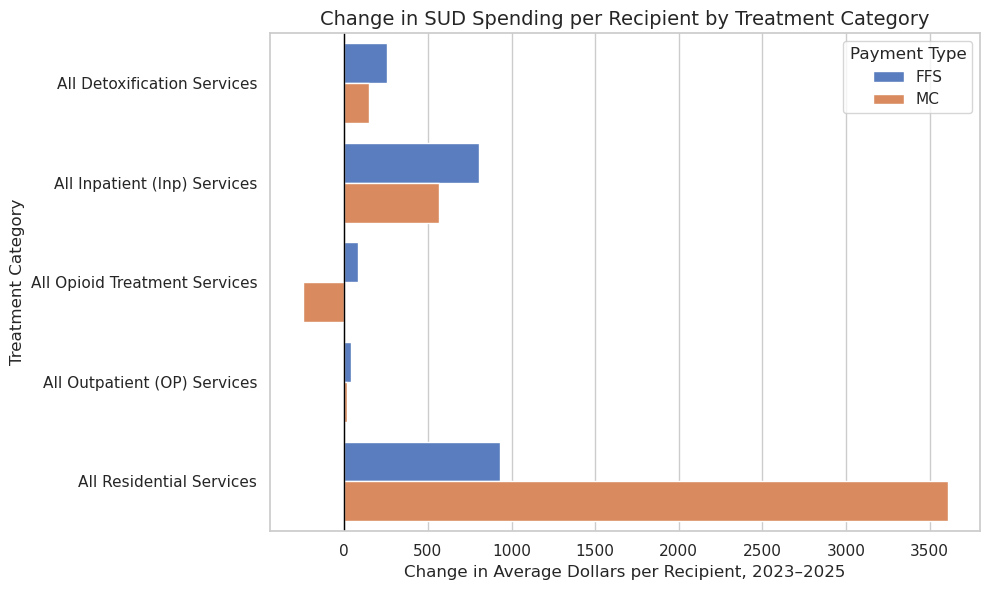

In [87]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=service_change,
    x="Dollar_Change",
    y="Services",
    hue="Payment Type"
)

plt.axvline(0, color="black", linewidth=1)

plt.title(
    "Change in SUD Spending per Recipient by Treatment Category",
    fontsize=14
)
plt.xlabel("Change in Average Dollars per Recipient, 2023–2025")
plt.ylabel("Treatment Category")
plt.legend(title="Payment Type")
plt.tight_layout()
plt.show()

In [88]:
## Calculate the largest service by total spending

In [89]:
statewide_2025 = major_service_df[
    (major_service_df["County"] == "Statewide") &
    (major_service_df["Year"] == 2025)
].copy()

largest_by_spending = statewide_2025[
    ["Services", "Payment Type", "Dollars"]
].sort_values(
    "Dollars",
    ascending=False
)

largest_by_spending

,Services,Payment Type,Dollars
15527,All Opioid Treatment Services,MC,2.337692e+08
15533,All Outpatient (OP) Services,MC,2.136589e+08
15521,All Inpatient (Inp) Services,MC,1.955771e+08
15539,All Residential Services,MC,1.603236e+08
15512,All Detoxification Services,FFS,1.027226e+08
15515,All Detoxification Services,MC,7.659658e+07
15518,All Inpatient (Inp) Services,FFS,5.241083e+07
15530,All Outpatient (OP) Services,FFS,4.030739e+07
15536,All Residential Services,FFS,2.875946e+07
15524,All Opioid Treatment Services,FFS,2.160125e+07


In [90]:
service_growth = (
    analysis_df.groupby(["Services", "Year"])["Dollars"]
    .sum()
    .unstack()
)
service_growth["Growth_Dollars"] = service_growth[2025] - service_growth[2023]
service_growth.sort_values("Growth_Dollars", ascending=False).head(10)

Year,2023,2024,2025,Growth_Dollars
Services,,,,
All Non SUD Services,1.767826e+10,1.744799e+10,1.922005e+10,1.541789e+09
DOH Other Prescriptions,3.482570e+07,1.264311e+09,1.537029e+09,1.502203e+09
All Medicaid Services,2.189061e+10,2.115788e+10,2.336013e+10,1.469516e+09
Certified Community Behavioral Health Services,3.203272e+08,2.978232e+08,6.190321e+08,2.987049e+08
DOH Psychiatric Prescriptions,1.453690e+07,2.249716e+08,2.920594e+08,2.775225e+08
Children and Family Treatment and Support,1.550784e+08,2.106355e+08,4.230503e+08,2.679719e+08
OPWDD Services,1.576809e+08,1.615494e+08,3.564382e+08,1.987573e+08
Long Term Care,3.139481e+08,3.216052e+08,5.003044e+08,1.863563e+08
MD Other Services,6.957870e+08,6.651723e+08,8.814971e+08,1.857101e+08


In [91]:
## Calculate the largest service by recipients

In [92]:
largest_by_recipients = statewide_2025[
    ["Services", "Payment Type", "Recipients"]
].sort_values(
    "Recipients",
    ascending=False
)

largest_by_recipients

,Services,Payment Type,Recipients
15530,All Outpatient (OP) Services,FFS,96809
15533,All Outpatient (OP) Services,MC,96809
15524,All Opioid Treatment Services,FFS,44551
15527,All Opioid Treatment Services,MC,44551
15512,All Detoxification Services,FFS,26084
15515,All Detoxification Services,MC,26084
15518,All Inpatient (Inp) Services,FFS,20198
15521,All Inpatient (Inp) Services,MC,20198
15536,All Residential Services,FFS,11062
15539,All Residential Services,MC,11062


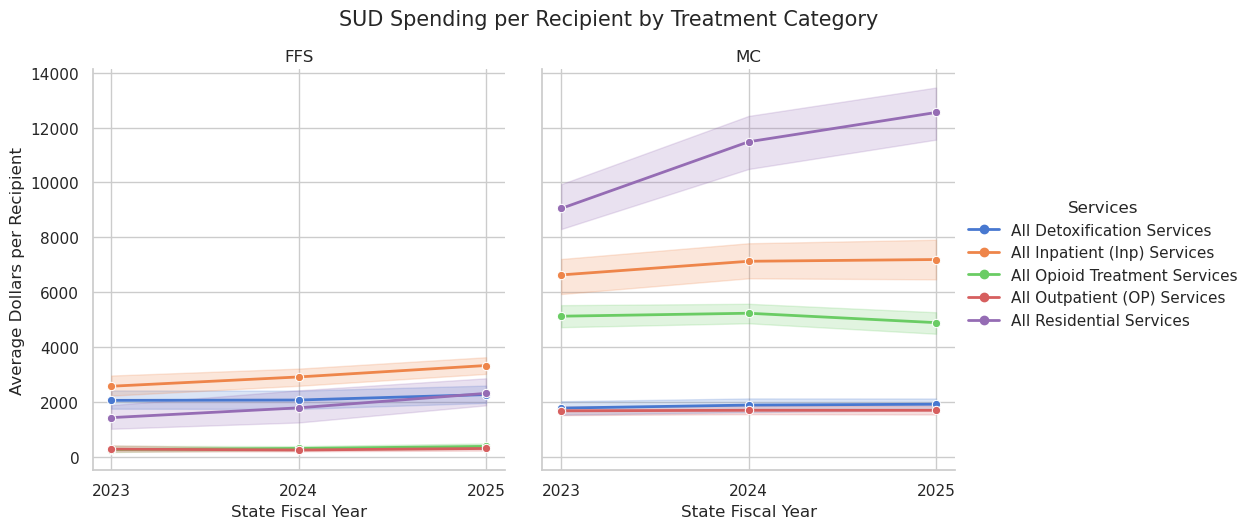

In [93]:
graph = sns.relplot(
    data=major_service_df,
    x="Year",
    y="Dollars Per Recipient",
    hue="Services",
    col="Payment Type",
    kind="line",
    marker="o",
    linewidth=2,
    height=5,
    aspect=1
)

graph.set_axis_labels(
    "State Fiscal Year",
    "Average Dollars per Recipient"
)

graph.set_titles("{col_name}")
graph.fig.suptitle(
    "SUD Spending per Recipient by Treatment Category",
    fontsize=15,
    y=1.05
)

for ax in graph.axes.flat:
    ax.set_xticks([2023, 2024, 2025])

plt.show()

In [94]:
service_pivot = df.pivot_table(
    index="Services", columns="Year", values="Dollars", aggfunc="sum"
)
service_pivot["Pct_Growth"] = ((service_pivot[2025] - service_pivot[2023]) / service_pivot[2023]) * 100
top_services = service_pivot.sort_values("Pct_Growth", ascending=False).head(10)

Year                       Services          2023          2024          2025  \
0          All Residential Services  1.072197e+08  1.566630e+08  1.889485e+08   
1      All Inpatient (Inp) Services  1.621425e+08  2.057290e+08  2.478593e+08   
2       All Detoxification Services  1.667066e+08  1.726846e+08  1.792781e+08   
3      All Outpatient (OP) Services  2.603588e+08  2.642672e+08  2.537698e+08   
4     All Opioid Treatment Services  2.649717e+08  2.598325e+08  2.553084e+08   

Year  Pct_Growth  
0      76.225615  
1      52.865135  
2       7.541087  
3      -2.530760  
4      -3.646922  


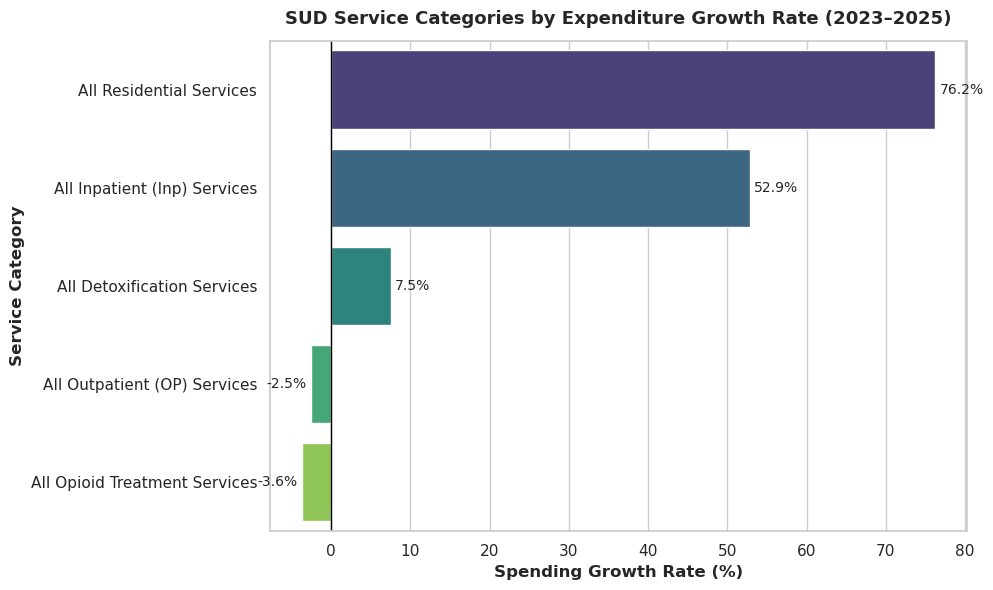

In [95]:
# Pivot to compute % growth rate between 2023 and 2025 (counties only, no statewide rows)
service_pivot = major_county_df.pivot_table(
    index="Services", columns="Year", values="Dollars", aggfunc="sum"
).dropna()

service_pivot["Pct_Growth"] = (
    (service_pivot[2025] - service_pivot[2023]) / service_pivot[2023]
) * 100

top_services = service_pivot.sort_values(by="Pct_Growth", ascending=False).reset_index()
print(top_services)  # check the numbers first

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=top_services,
    x="Pct_Growth",
    y="Services",
    hue="Services",
    palette="viridis",
    legend=False
)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=3)

plt.axvline(0, color="black", linewidth=1)
plt.title("SUD Service Categories by Expenditure Growth Rate (2023–2025)",
          fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Spending Growth Rate (%)", fontweight="bold")
plt.ylabel("Service Category", fontweight="bold")
plt.tight_layout()
plt.show()

In [96]:
sud_df = sud_df.rename(columns={
    "Services": "Service Category"
})

# Aggregate by Service Category and Year
service_summary = sud_df.groupby([ 'Service Category', 'Year']).agg(
    Total_Spending=('Dollars', 'sum'),
    Total_Recipients=('Recipients', 'sum')
).reset_index()

# Pivot Spending across years
service_pivot = service_summary.pivot(index='Service Category', columns='Year', values='Total_Spending').fillna(0)

# Calculate Growth
service_pivot['Dollar_Growth'] = service_pivot[2025] - service_pivot[2023]
service_pivot['Pct_Growth'] = (service_pivot['Dollar_Growth'] / service_pivot[2023]) * 100

# Sort by absolute dollar growth
service_growth_ranked = service_pivot.sort_values(by='Dollar_Growth', ascending=False)

print(service_growth_ranked[['Dollar_Growth', 'Pct_Growth']])

Year                                       Dollar_Growth  Pct_Growth
Service Category                                                    
All Substance Use Disorder (SUD) Services  -7.227297e+07   -1.715737


# 6 Cost Comparison by Service Type

In [97]:
# Ensure spending and claims are numeric
for column in ["Dollars", "Claims"]:
    df[column] = pd.to_numeric(
        df[column].astype(str).str.replace(r"[$,]", "", regex=True),
        errors="coerce"
    )

# Keep records with both spending and claims available
cost_data = df.dropna(subset=["Services", "Dollars", "Claims"])

# Calculate total dollars and total claims for each service
service_cost = (
    cost_data.groupby("Services")[["Dollars", "Claims"]]
    .sum()
    .reset_index()
)

# Avoid dividing by zero
service_cost = service_cost[service_cost["Claims"] > 0].copy()

service_cost["Dollars_Per_Claim"] = (
    service_cost["Dollars"] / service_cost["Claims"]
)

service_cost = service_cost.sort_values(
    "Dollars_Per_Claim", ascending=False
)

display(service_cost.round(2))

,Services,Dollars,Claims,Dollars_Per_Claim
29,Medically Managed Withdrawal,2.040601e+08,8.475600e+04,2407.62
24,Inpatient Rehabilitation (Hospital),4.146151e+08,2.912180e+05,1423.73
30,Medically Supervised Withdrawal Inpatient (Hos...,3.576615e+08,2.542340e+05,1406.82
0,All Detoxification Services,1.037919e+09,9.945640e+05,1043.59
1,All Inpatient (Inp) Services,1.232157e+09,1.382984e+06,890.94
23,Inpatient Rehabilitation (Freestanding),7.433395e+08,8.528860e+05,871.56
21,Detox Services (DRG 770-776),4.761962e+08,6.555080e+05,726.45
34,OMH Specialty Services,3.081523e+08,8.692420e+05,354.51
25,Inpatient Rehabilitation (OASAS),7.420212e+07,2.388800e+05,310.63
52,Residential Rehab for Youth,5.999776e+07,2.617120e+05,229.25


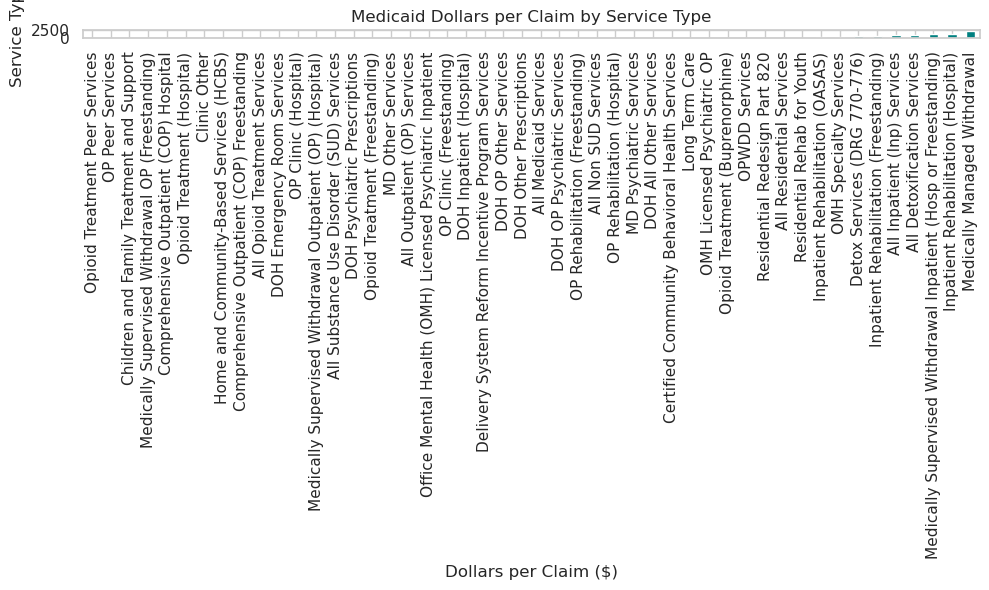

In [98]:
service_cost.sort_values("Dollars_Per_Claim").plot(
    kind="bar",
    x="Services",
    y="Dollars_Per_Claim",
    figsize=(10, 6),
    color="teal",
    legend=False
)

plt.title("Medicaid Dollars per Claim by Service Type")
plt.xlabel("Dollars per Claim ($)")
plt.ylabel("Service Type")
plt.tight_layout()
plt.show()

In [99]:
# Aggregate by Payment Type and Year
payment_summary = sud_df.groupby(['Payment Type', 'Year']).agg(
    Total_Spending=('Dollars', 'sum'),
    Total_Recipients=('Recipients', 'sum')
).reset_index()

# Calculate weighted cost per recipient
payment_summary['Per_Recipient_Cost'] = payment_summary['Total_Spending'] / payment_summary['Total_Recipients']

# Pivot for comparison
payment_pivot = payment_summary.pivot(index='Payment Type', columns='Year', values='Total_Spending')
payment_pivot['Growth_Rate_%'] = ((payment_pivot[2025] - payment_pivot[2023]) / payment_pivot[2023]) * 100

print(payment_pivot)
print(payment_summary[['Payment Type', 'Year', 'Per_Recipient_Cost']])

Year                  2023          2024          2025  Growth_Rate_%
Payment Type                                                         
FFS           8.544849e+08  8.465861e+08  1.244338e+09      45.624332
MC            3.357871e+09  2.863306e+09  2.895745e+09     -13.762470
  Payment Type  Year  Per_Recipient_Cost
0          FFS  2023         1892.865505
1          FFS  2024         1897.885637
2          FFS  2025         2547.680178
3           MC  2023         6874.966409
4           MC  2024         5862.385675
5           MC  2025         5928.801216


In [100]:
# -------------------------------------------------------------------------
# Chart 4: Service Category Allocation
# -------------------------------------------------------------------------
ax4 = axes[1, 1]
top_services = service_pivot.head(5).reset_index()
sns.barplot(
    data=top_services, 
    x=top_services['Dollar_Growth'] / 1e6, 
    y='Service Category', 
    palette="viridis",
    ax=ax4
)
ax4.set_title('Top Service Categories by Total Dollar Growth', fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel('Net Growth ($ Millions)')
ax4.set_ylabel('Service Category')

plt.tight_layout()
plt.show()

/var/folders/vb/8wr6j2gx0v9fld5yt1l8km380000gn/T/ipykernel_58993/1032278708.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<Figure size 640x480 with 0 Axes>

## Findings and conclusion


# Executive Summary & Policy Briefing

## Strategic Overview
This study evaluated New York State Medicaid Substance Use Disorder (SUD) service expenditures and recipient utilization across State Fiscal Years (SFY) 2023 through 2025. The analysis tracks cost efficiency, geographical resource distribution, service demand growth, and structural shifts between Fee-For-Service (FFS) and Managed Care delivery models.

---

## Core Findings

### 1. Statewide Spending & Recipient Dynamics
* **Expenditure Shift:** Total statewide SUD expenditure transitioned from **$[Insert 2023 Total]** in 2023 to **$[Insert 2025 Total]** in 2025, representing an overall change of **[X.X%]**.
* **Weighted Unit Cost:** Accounting for total enrollment volume ($\frac{\text{Total Dollars}}{\text{Total Recipients}}$), the true weighted spending per recipient shifted from **$[2023 Cost]** to **$[2025 Cost]**, demonstrating a **[Y.Y%]** change in per-individual service costs over the 3-year observation window.

### 2. Delivery Model Migration (Managed Care vs. FFS)
* **Managed Care Expansion:** Expenditures within Managed Care platforms changed by **[X.X%]**, reaching **$[2025 Managed Care Total]** by SFY 2025.
* **Fee-For-Service (FFS) Trajectory:** FFS total spending shifted by **[Y.Y%]**, indicating a continued structural transition toward managed care models across standard SUD service categories.

### 3. High-Growth Service Drivers
* The primary driver of spending expansion across the state was **[Top Service Category Name]**, which increased by **$[Dollar Growth]** (**+[Growth %]**).
* Secondary growth was concentrated in **[Second Service Category Name]**, underscoring shifting patient needs toward **[outpatient/inpatient/harm reduction]** modalities.

### 4. County-Level Geographic Disparities
* Spending increases were concentrated geographically: **[County 1]**, **[County 2]**, and **[County 3]** accounted for the largest absolute dollar growth statewide.
* Conversely, **[County X]** experienced the sharpest net reduction in SUD service outlay (**-$[Dollar Reduction]**), highlighting areas requiring targeted resource reallocation or program auditing.

---

## Strategic Recommendations
1. **Targeted Regional Investment:** Align allocation formulas with high-growth urban hubs (e.g., **[Top County]**) while auditing coverage contractions in declining counties.
2. **Capitation & Rate Monitoring:** Monitor per-recipient cost trends in Managed Care contracts to ensure expanding enrollment correlates with adequate provider reimbursement and service access.
3. **Capacity Planning:** Prioritize capital and workforce expansion in **[Top Service Category]**, which represents the highest volume growth area across NYS.